This download is being doen to try the Code found here 
https://github.com/Gisat/S14amazonas/
imported data have clouds, so it will not produce a best result. Maybe there are other ways to get cloud-free data
code above expects data to be named in certain format, we are still running tests to see what needs to be done


use google earth engine to export images
- its a first pass script. data need to be checked etc

data are exported to user's google drive "GEE_exports"
after running, monitor drive - it takes time for all the images

you can monitor export tasks here
https://code.earthengine.google.com/tasks



if you need to change script and run it again, cancel running tasks here
https://code.earthengine.google.com/tasks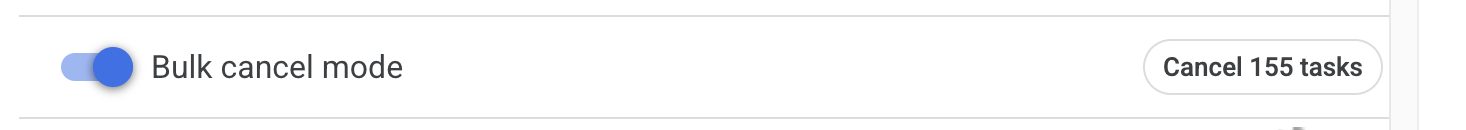

area being exported is here 
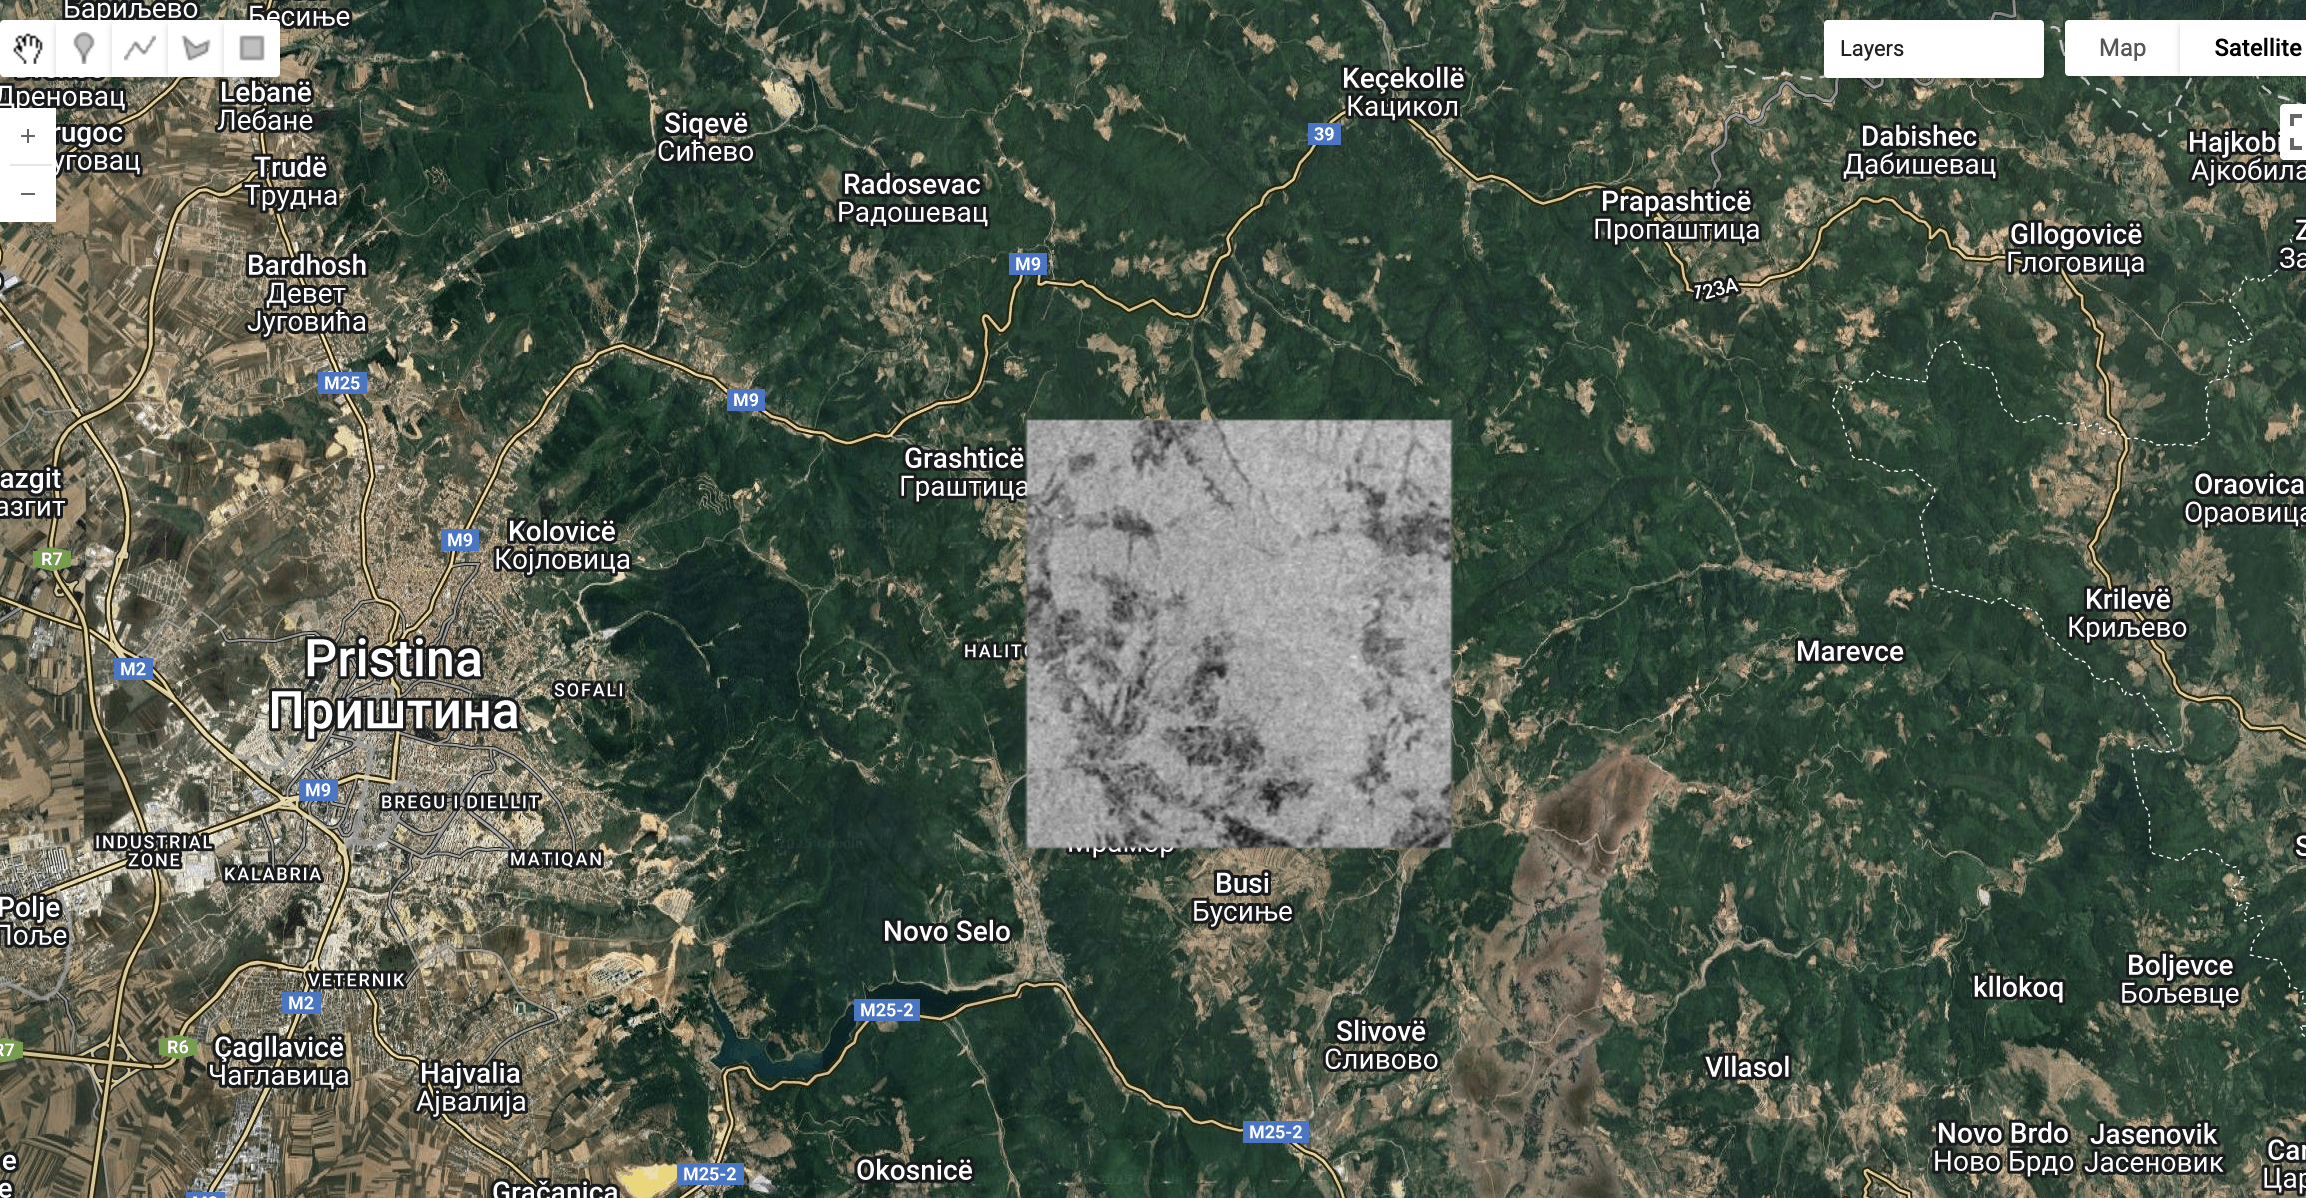

this covers area surveyed by drone for 2025

In [4]:
# %pip install earthengine-api

# Import the Earth Engine library
import ee

# Authenticate with Earth Engine
ee.Authenticate()

# Initialize the Earth Engine API
ee.Initialize()


Successfully saved authorization token.


In [11]:
# CONFIG
YEAR = 2022  # Change to 2023, 2024, etc.
center = ee.Geometry.Point([21.3092915, 42.6736154])
aoi = center.buffer(3000).bounds()  # ~6x6 km box
crs = 'EPSG:32634'  # Kosovo UTM 34N
s1WindowDays = 6  # +/- 6 days (12-day composite)
s1Scale = 10  # 10 m native for S1
s2Scale = 10  # 10 m native for S2
driveFolder = 'GEE_exports'  # Your Drive folder

# HELPERS
def date_list_12_day(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = ee.Date.fromYMD(year, 12, 31)
    step = 12  # days
    n = end.difference(start, 'day').divide(step).floor()
    return ee.List.sequence(0, n).map(lambda i: start.advance(ee.Number(i).multiply(step), 'day'))

def month_starts(year):
    return ee.List.sequence(1, 12).map(lambda m: ee.Date.fromYMD(year, ee.Number(m), 1))

def s1_composite(start_date, days_window, pol):
    start = ee.Date(start_date).advance(-days_window, 'day')
    end = ee.Date(start_date).advance(days_window, 'day')
    return ee.ImageCollection('COPERNICUS/S1_GRD') \
        .filterBounds(aoi) \
        .filterDate(start, end) \
        .filter(ee.Filter.eq('instrumentMode', 'IW')) \
        .filter(ee.Filter.eq('resolution_meters', 10)) \
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', pol)) \
        .select([pol]) \
        .median() \
        .clip(aoi)

def mask_s2_sr(img):
    qa = img.select('QA60')
    cloud = qa.bitwiseAnd(1 << 10).neq(0).Or(qa.bitwiseAnd(1 << 11).neq(0))
    return img.updateMask(cloud.Not())

def s2_monthly_composite(month_start):
    start = ee.Date(month_start)
    end = start.advance(1, 'month')
    coll = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterBounds(aoi).filterDate(start, end) \
        .map(mask_s2_sr)
    # Fallback: widen window if empty
    is_empty = coll.size().eq(0)
    coll_wide = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterBounds(aoi).filterDate(start.advance(-15, 'day'), end.advance(15, 'day')) \
        .map(mask_s2_sr)
    chosen = ee.ImageCollection(ee.Algorithms.If(is_empty, coll_wide, coll))
    return chosen.median().clip(aoi)

# SENTINEL-1 — 12-day series (VV & VH)
centers = date_list_12_day(YEAR)
n = centers.length().getInfo()
print('S1 centers count:', n)

for i in range(n):
    d = ee.Date(centers.get(i))  # Server-side date
    ymd = d.format('YYYYMMdd').getInfo()  # Server-side string

    vv = s1_composite(d, s1WindowDays, 'VV')
    vh = s1_composite(d, s1WindowDays, 'VH')

    # Exports (names match repo expectation)
    task_vv = ee.batch.Export.image.toDrive(
        image=vv.multiply(100).int16(),
        description=f'KOSBOX_backscatter_VV_PC_{ymd}',
        folder=driveFolder,
        fileNamePrefix=f'KOSBOX_backscatter_VV_PC_{ymd}',
        region=aoi,
        scale=s1Scale,
        crs=crs,
        maxPixels=1e9
    )
    task_vv.start()

    task_vh = ee.batch.Export.image.toDrive(
        image=vh.multiply(100).int16(),
        description=f'KOSBOX_backscatter_VH_PC_{ymd}',
        folder=driveFolder,
        fileNamePrefix=f'KOSBOX_backscatter_VH_PC_{ymd}',
        region=aoi,
        scale=s1Scale,
        crs=crs,
        maxPixels=1e9
    )
    task_vh.start()

# SENTINEL-2 — Monthly optical (RGB + bands + NDVI)
for m in range(1, 13):
    ms = ee.Date.fromYMD(YEAR, m, 1)
    s2 = s2_monthly_composite(ms)
    yyyymm = ms.format('YYYYMM').getInfo()

    ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI')

    task_rgb = ee.batch.Export.image.toDrive(
        image=s2.select(['B4', 'B3', 'B2']),
        description=f'KOSBOX_S2_RGB_{yyyymm}',
        folder=driveFolder,
        fileNamePrefix=f'KOSBOX_S2_RGB_{yyyymm}',
        region=aoi,
        scale=s2Scale,
        crs=crs,
        maxPixels=1e9
    )
    task_rgb.start()

    task_bands = ee.batch.Export.image.toDrive(
        image=s2.select(['B2', 'B3', 'B4', 'B8']),
        description=f'KOSBOX_S2_BANDS_{yyyymm}',
        folder=driveFolder,
        fileNamePrefix=f'KOSBOX_S2_BANDS_{yyyymm}',
        region=aoi,
        scale=s2Scale,
        crs=crs,
        maxPixels=1e9
    )
    task_bands.start()

    task_ndvi = ee.batch.Export.image.toDrive(
        image=ndvi.multiply(10000).int16(),
        description=f'KOSBOX_S2_NDVI_{yyyymm}',
        folder=driveFolder,
        fileNamePrefix=f'KOSBOX_S2_NDVI_{yyyymm}',
        region=aoi,
        scale=s2Scale,
        crs=crs,
        maxPixels=1e9
    )
    task_ndvi.start()

# AUX DATA for the repo (export once per YEAR=any)
# DEM
dem = ee.Image('USGS/SRTMGL1_003').clip(aoi)
task_dem = ee.batch.Export.image.toDrive(
    image=dem,
    description='SRTM_Kosovo_30m',
    folder=driveFolder,
    fileNamePrefix='SRTM_Kosovo_30m',
    region=aoi,
    scale=30,
    crs=crs,
    maxPixels=1e9
)
task_dem.start()

# Forest mask (quick NDVI-based DEMO)
summer = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(aoi).filterDate(ee.Date.fromYMD(YEAR, 6, 1), ee.Date.fromYMD(YEAR, 8, 31)) \
    .map(mask_s2_sr).median().clip(aoi)
summer_ndvi = summer.normalizedDifference(['B8', 'B4'])
forest_mask = summer_ndvi.gt(0.6).rename('forest')  # Demo threshold
task_forest = ee.batch.Export.image.toDrive(
    image=forest_mask.uint8(),
    description='ESACCI-LC-L4-LCCS-Map-300m-2015_Amazon_only30to90_20m',
    folder=driveFolder,
    fileNamePrefix='ESACCI-LC-L4-LCCS-Map-300m-2015_Amazon_only30to90_20m',
    region=aoi,
    scale=20,
    crs=crs,
    maxPixels=1e9
)
task_forest.start()

S1 centers count: 31
